# Model Training - Energy Theft Detection

Notebook này hoàn thiện bước training cho project phát hiện trộm điện. Dữ liệu đầu vào là `data/processed/features.csv`, được sinh từ `src/preprocessing_v2.py` và `src/feature.py`.

Trọng tâm của notebook:

- Giữ `Logistic Regression + L2 + balanced` làm baseline tuyến tính để so sánh và giải thích.
- Thêm `Random Forest` làm bagging benchmark với cấu hình từ `model_training_first_version.ipynb`.
- Giữ `LightGBM` là benchmark hiệu năng chính trên dữ liệu tabular.
- Đánh giá bằng Recall, F1/F2, PR-AUC, ROC-AUC và Confusion Matrix thay vì chỉ nhìn Accuracy.
- Tune threshold trên validation set, không dùng test set để chọn model hoặc threshold.


## 1. Setup

Logistic Regression dùng `StandardScaler` fit trên train set. Tree-based models như Random Forest và LightGBM không cần scaling, nhưng vẫn dùng cùng train/validation/test split và cùng feature set để so sánh công bằng.


In [1]:
from pathlib import Path
import importlib.util
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"
QUALITY_PATH = PROJECT_ROOT / "data" / "processed" / "quality_features.csv"

ID_COL = "CONS_NO"
TARGET_COL = "FLAG"
RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

HAS_LIGHTGBM = importlib.util.find_spec("lightgbm") is not None

print(f"Project root: {PROJECT_ROOT}")
print(f"Features path: {FEATURES_PATH}")
print(f"Split ratio: train={TRAIN_SIZE:.0%}, validation={VALIDATION_SIZE:.0%}, test={TEST_SIZE:.0%}")
print(f"LightGBM available: {HAS_LIGHTGBM}")


Project root: C:\Users\asus\Documents\HocTap\HK4\CS114 - Machine Learning\CS114 -  ML Project - Energy Theft Detection
Features path: C:\Users\asus\Documents\HocTap\HK4\CS114 - Machine Learning\CS114 -  ML Project - Energy Theft Detection\data\processed\features.csv
Split ratio: train=70%, validation=15%, test=15%
LightGBM available: True


## 2. Load và kiểm tra feature table

`CONS_NO` chỉ dùng để trace khách hàng khi phân tích lỗi. Model không được dùng `CONS_NO` làm feature. Target là `FLAG`, trong đó `0 = Normal`, `1 = Theft`.


,Mục,Giá trị
0,Số khách hàng,42372
1,Số cột trong features.csv,163
2,Số feature ban đầu,161
3,Missing trong feature,0
4,Inf trong feature,0


,Số lượng,Tỷ lệ
FLAG,,
Normal,38757,0.914684
Theft,3615,0.085316


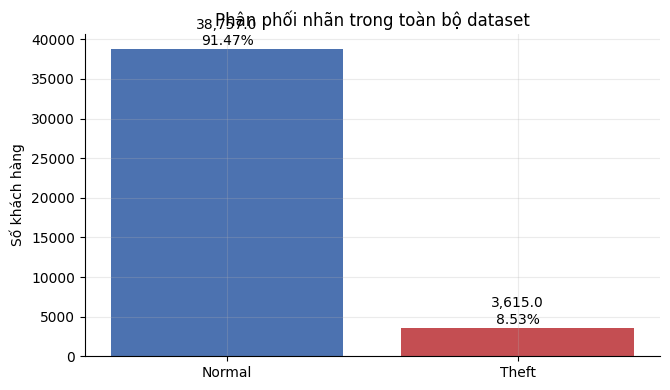

In [2]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(f"Không tìm thấy feature table: {FEATURES_PATH}")

features_df = pd.read_csv(FEATURES_PATH)
required_cols = {ID_COL, TARGET_COL}
missing_required = required_cols - set(features_df.columns)
if missing_required:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_required}")

feature_cols_all = [col for col in features_df.columns if col not in [ID_COL, TARGET_COL]]
X_all = features_df[feature_cols_all].copy()
y_all = features_df[TARGET_COL].astype(int).copy()
ids_all = features_df[ID_COL].copy()

n_missing = int(X_all.isna().sum().sum())
n_inf = int(np.isinf(X_all.to_numpy(dtype=np.float64)).sum())
if n_missing or n_inf:
    raise ValueError(f"Feature matrix chưa sạch: missing={n_missing}, inf={n_inf}")

summary = pd.DataFrame({
    "Mục": ["Số khách hàng", "Số cột trong features.csv", "Số feature ban đầu", "Missing trong feature", "Inf trong feature"],
    "Giá trị": [len(features_df), features_df.shape[1], len(feature_cols_all), n_missing, n_inf],
})
display(summary)

target_table = y_all.value_counts().sort_index().rename(index={0: "Normal", 1: "Theft"}).to_frame("Số lượng")
target_table["Tỷ lệ"] = target_table["Số lượng"] / len(y_all)
display(target_table)

fig, ax = plt.subplots(figsize=(6.8, 4))
colors = ["#4C72B0", "#C44E52"]
ax.bar(target_table.index, target_table["Số lượng"], color=colors)
ax.set_title("Phân phối nhãn trong toàn bộ dataset")
ax.set_ylabel("Số khách hàng")
for idx, (label, row) in enumerate(target_table.iterrows()):
    ax.text(idx, row["Số lượng"] + 500, f"{row['Số lượng']:,}\n{row['Tỷ lệ']:.2%}", ha="center")
plt.tight_layout()


## 3. Train / Validation / Test split

Split được stratify theo `FLAG` để tỷ lệ Normal/Theft trong từng tập gần giống toàn bộ dataset. Test set chỉ được dùng ở bước final evaluation.


,Tập dữ liệu,Rows,Normal,Theft,Theft ratio
0,Full,42372,38757,3615,0.085316
1,Train,29660,27130,2530,0.085300
2,Validation,6356,5813,543,0.085431
3,Test,6356,5814,542,0.085274


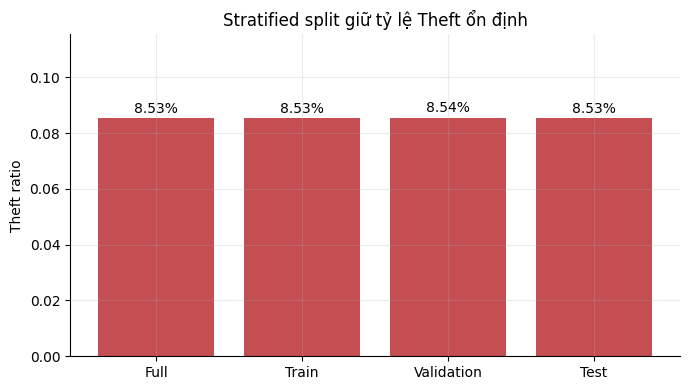

In [3]:
temp_size = VALIDATION_SIZE + TEST_SIZE
relative_test_size = TEST_SIZE / temp_size

X_train_raw, X_temp_raw, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X_all,
    y_all,
    ids_all,
    test_size=temp_size,
    random_state=RANDOM_STATE,
    stratify=y_all,
)
X_val_raw, X_test_raw, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp_raw,
    y_temp,
    ids_temp,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train_raw = X_train_raw.reset_index(drop=True)
X_val_raw = X_val_raw.reset_index(drop=True)
X_test_raw = X_test_raw.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)
ids_train = ids_train.reset_index(drop=True)
ids_val = ids_val.reset_index(drop=True)
ids_test = ids_test.reset_index(drop=True)

split_report = pd.DataFrame([
    {"Tập dữ liệu": "Full", "Rows": len(y_all), "Normal": int((y_all == 0).sum()), "Theft": int((y_all == 1).sum()), "Theft ratio": y_all.mean()},
    {"Tập dữ liệu": "Train", "Rows": len(y_train), "Normal": int((y_train == 0).sum()), "Theft": int((y_train == 1).sum()), "Theft ratio": y_train.mean()},
    {"Tập dữ liệu": "Validation", "Rows": len(y_val), "Normal": int((y_val == 0).sum()), "Theft": int((y_val == 1).sum()), "Theft ratio": y_val.mean()},
    {"Tập dữ liệu": "Test", "Rows": len(y_test), "Normal": int((y_test == 0).sum()), "Theft": int((y_test == 1).sum()), "Theft ratio": y_test.mean()},
])
display(split_report)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(split_report["Tập dữ liệu"], split_report["Theft ratio"], color="#C44E52")
ax.set_ylabel("Theft ratio")
ax.set_title("Stratified split giữ tỷ lệ Theft ổn định")
ax.set_ylim(0, max(split_report["Theft ratio"]) * 1.35)
for idx, value in enumerate(split_report["Theft ratio"]):
    ax.text(idx, value + 0.002, f"{value:.2%}", ha="center")
plt.tight_layout()


## 4. Kiểm tra leakage và feature hygiene

Các feature hằng số được phát hiện trên train set rồi loại khỏi toàn bộ split. Việc này không dùng thông tin validation/test để quyết định tiền xử lý.


In [4]:
assert len(X_train_raw) + len(X_val_raw) + len(X_test_raw) == len(X_all)
assert ids_train.isin(ids_val).sum() == 0, "Có overlap giữa train và validation"
assert ids_train.isin(ids_test).sum() == 0, "Có overlap giữa train và test"
assert ids_val.isin(ids_test).sum() == 0, "Có overlap giữa validation và test"

constant_cols = [col for col in X_train_raw.columns if X_train_raw[col].nunique(dropna=False) <= 1]
active_feature_cols = [col for col in X_train_raw.columns if col not in constant_cols]

X_train = X_train_raw[active_feature_cols].copy()
X_val = X_val_raw[active_feature_cols].copy()
X_test = X_test_raw[active_feature_cols].copy()

hygiene_report = pd.DataFrame({
    "Mục kiểm tra": [
        "Customer overlap giữa các split",
        "Feature ban đầu",
        "Feature hằng số bị loại",
        "Feature dùng cho model",
        "Missing train/val/test",
    ],
    "Kết quả": [
        0,
        len(feature_cols_all),
        len(constant_cols),
        len(active_feature_cols),
        f"{int(X_train.isna().sum().sum())} / {int(X_val.isna().sum().sum())} / {int(X_test.isna().sum().sum())}",
    ],
})
display(hygiene_report)
display(pd.DataFrame({"Feature hằng số bị loại": constant_cols}))


,Mục kiểm tra,Kết quả
0,Customer overlap giữa các split,0
1,Feature ban đầu,161
2,Feature hằng số bị loại,2
3,Feature dùng cho model,159
4,Missing train/val/test,0 / 0 / 0


,Feature hằng số bị loại
0,negative_count_raw
1,negative_ratio_raw


## 5. Hàm đánh giá và tune threshold

Threshold là ngưỡng đổi score/probability thành nhãn `0/1`. Vì class Theft chỉ khoảng 8.5%, threshold mặc định `0.50` thường bỏ sót nhiều theft. Notebook so sánh nhiều policy threshold trên validation set.


In [5]:
def safe_score(estimator, X, score_kind="predict_proba"):
    if score_kind == "predict_proba":
        return estimator.predict_proba(X)[:, 1]
    raise ValueError(f"Unsupported score_kind: {score_kind}")


def metrics_at_threshold(y_true, score, threshold):
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, score),
        "pr_auc": average_precision_score(y_true, score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def threshold_grid(score):
    return np.unique(np.r_[np.linspace(0, 1, 501), np.quantile(score, np.linspace(0, 1, 501))])


def tune_thresholds(y_true, score):
    curve = pd.DataFrame([metrics_at_threshold(y_true, score, t) for t in threshold_grid(score)])
    choices = {
        "default_0_50": metrics_at_threshold(y_true, score, 0.50),
        "best_f1": curve.loc[curve["f1"].idxmax()].to_dict(),
        "best_f2": curve.loc[curve["f2"].idxmax()].to_dict(),
    }
    for target_recall in [0.65, 0.80]:
        eligible = curve[curve["recall"] >= target_recall]
        key = f"recall_at_least_{str(target_recall).replace('.', '_')}"
        choices[key] = eligible.loc[eligible["f1"].idxmax()].to_dict() if len(eligible) else curve.loc[curve["recall"].idxmax()].to_dict()
    return choices, curve


def compact_metrics(row):
    keys = ["threshold", "accuracy", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"]
    return {key: row[key] for key in keys}

print("Đã chuẩn bị hàm metric và threshold tuning. Test set chưa được dùng ở bước này.")


Đã chuẩn bị hàm metric và threshold tuning. Test set chưa được dùng ở bước này.


## 6. Train candidate models

Notebook giữ ba model để so sánh gọn:

- **Baseline tuyến tính**: `Logistic Regression + L2 + balanced`, phù hợp để giải thích hệ số và xử lý dữ liệu mất cân bằng.
- **Bagging benchmark**: `Random Forest`, dùng cấu hình tốt nhất từ `model_training_first_version.ipynb`, chạy trên cùng feature set hiện tại sau khi loại feature hằng số.
- **Boosting benchmark**: `LightGBM`, dùng `scale_pos_weight` theo tỷ lệ mất cân bằng trên train set.


In [6]:
model_specs = [
    {
        "key": "logistic_l2_balanced",
        "display_name": "Logistic Regression + L2 + balanced",
        "group": "Linear baseline",
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="lbfgs",
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ]),
        "score_kind": "predict_proba",
    },
    {
        "key": "random_forest",
        "display_name": "Random Forest benchmark",
        "group": "Bagging",
        "estimator": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "score_kind": "predict_proba",
    },
]

scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())

if HAS_LIGHTGBM:
    from lightgbm import LGBMClassifier

    model_specs.append({
        "key": "lightgbm",
        "display_name": "LightGBM benchmark",
        "group": "Boosting",
        "estimator": LGBMClassifier(
            n_estimators=450,
            learning_rate=0.035,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=5,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "score_kind": "predict_proba",
    })
else:
    print("LightGBM chưa được cài, notebook sẽ chỉ train Logistic Regression và Random Forest.")

print(f"scale_pos_weight = {scale_pos_weight:.2f}")
print("Danh sách model sẽ train:")
display(pd.DataFrame([{k: spec[k] for k in ["key", "display_name", "group"]} for spec in model_specs]))


scale_pos_weight = 10.72
Danh sách model sẽ train:


,key,display_name,group
0,logistic_l2_balanced,Logistic Regression + L2 + balanced,Linear baseline
1,random_forest,Random Forest benchmark,Bagging
2,lightgbm,LightGBM benchmark,Boosting


In [7]:
model_results = {}
training_rows = []

for spec in model_specs:
    started = time.perf_counter()
    estimator = clone(spec["estimator"])
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started

    val_score = safe_score(estimator, X_val, spec["score_kind"])
    test_score = safe_score(estimator, X_test, spec["score_kind"])
    threshold_choices, threshold_curve = tune_thresholds(y_val, val_score)

    model_results[spec["key"]] = {
        **spec,
        "estimator": estimator,
        "fit_seconds": fit_seconds,
        "val_score": val_score,
        "test_score": test_score,
        "threshold_choices": threshold_choices,
        "threshold_curve": threshold_curve,
    }

    training_rows.append({
        "Model": spec["display_name"],
        "Group": spec["group"],
        "Fit seconds": fit_seconds,
        "Val ROC-AUC": threshold_choices["default_0_50"]["roc_auc"],
        "Val PR-AUC": threshold_choices["default_0_50"]["pr_auc"],
        "Val F1 @0.50": threshold_choices["default_0_50"]["f1"],
        "Val Recall @0.50": threshold_choices["default_0_50"]["recall"],
        "Best F1": threshold_choices["best_f1"]["f1"],
        "Best F1 threshold": threshold_choices["best_f1"]["threshold"],
        "Best F2": threshold_choices["best_f2"]["f2"],
        "Best F2 threshold": threshold_choices["best_f2"]["threshold"],
    })

training_summary = pd.DataFrame(training_rows)
display(training_summary.round(4))
print("Training hoàn tất cho các model được giữ lại.")


,Model,Group,Fit seconds,Val ROC-AUC,Val PR-AUC,Val F1 @0.50,Val Recall @0.50,Best F1,Best F1 threshold,Best F2,Best F2 threshold
0,Logistic Regression + L2 + balanced,Linear baseline,5.7975,0.8026,0.3494,0.3171,0.6851,0.3982,0.7020,0.4772,0.5400
1,Random Forest benchmark,Bagging,8.8260,0.8241,0.4219,0.4147,0.3646,0.4449,0.4658,0.5094,0.3000
2,LightGBM benchmark,Boosting,2.9122,0.8414,0.4902,0.4407,0.5948,0.4855,0.7060,0.5353,0.4368


Training hoàn tất cho các model được giữ lại.


## 7. Validation comparison và lựa chọn model

Notebook tách hai vai trò:

- **Model so sánh bắt buộc**: `Logistic Regression + L2 + balanced` và `Random Forest`.
- **Model hiệu năng tốt nhất**: chọn bằng validation Best F2 trong toàn bộ candidate models.


In [8]:
threshold_rows = []
for key, result in model_results.items():
    for threshold_name, metrics in result["threshold_choices"].items():
        threshold_rows.append({
            "model_key": key,
            "Model": result["display_name"],
            "Group": result["group"],
            "Threshold policy": threshold_name,
            **compact_metrics(metrics),
        })

threshold_report = pd.DataFrame(threshold_rows)
show_cols = ["Model", "Group", "Threshold policy", "threshold", "precision", "recall", "f1", "f2", "pr_auc", "roc_auc", "fp", "fn", "tp"]
display(threshold_report[show_cols].round(4))

core_report_key = "logistic_l2_balanced"
core_report_policy = "best_f2"
core_report_threshold = float(model_results[core_report_key]["threshold_choices"][core_report_policy]["threshold"])

rf_report_key = "random_forest"
rf_report_threshold = float(model_results[rf_report_key]["threshold_choices"]["best_f2"]["threshold"])

best_f2_rows = threshold_report[threshold_report["Threshold policy"] == "best_f2"].copy()
best_perf_row = best_f2_rows.sort_values(["f2", "pr_auc"], ascending=False).iloc[0]
best_perf_key = best_perf_row["model_key"]
best_perf_threshold = float(best_perf_row["threshold"])
best_perf_name = best_perf_row["Model"]

selected_model_configs = [
    (core_report_key, core_report_threshold, "Baseline tuyến tính"),
    (rf_report_key, rf_report_threshold, "Bagging benchmark"),
]
if best_perf_key not in {key for key, _, _ in selected_model_configs}:
    selected_model_configs.append((best_perf_key, best_perf_threshold, "Mô hình hiệu năng tốt nhất"))

print("Model so sánh 1 - baseline tuyến tính:")
print(f"  {model_results[core_report_key]['display_name']} | threshold={core_report_threshold:.4f} | policy={core_report_policy}")
print("Model so sánh 2 - bagging benchmark:")
print(f"  {model_results[rf_report_key]['display_name']} | threshold={rf_report_threshold:.4f} | policy=best_f2")
print("Model hiệu năng tốt nhất trên validation:")
print(f"  {best_perf_name} | threshold={best_perf_threshold:.4f} | policy=best_f2")


,Model,Group,Threshold policy,threshold,precision,recall,f1,f2,pr_auc,roc_auc,fp,fn,tp
0,Logistic Regression + L2 + balanced,Linear baseline,default_0_50,0.5000,0.2063,0.6851,0.3171,0.4679,0.3494,0.8026,1431.0,171.0,372.0
1,Logistic Regression + L2 + balanced,Linear baseline,best_f1,0.7020,0.3833,0.4144,0.3982,0.4078,0.3494,0.8026,362.0,318.0,225.0
2,Logistic Regression + L2 + balanced,Linear baseline,best_f2,0.5400,0.2370,0.6390,0.3458,0.4772,0.3494,0.8026,1117.0,196.0,347.0
3,Logistic Regression + L2 + balanced,Linear baseline,recall_at_least_0_65,0.5256,0.2238,0.6501,0.3330,0.4708,0.3494,0.8026,1224.0,190.0,353.0
4,Logistic Regression + L2 + balanced,Linear baseline,recall_at_least_0_8,0.4302,0.1711,0.8011,0.2819,0.4613,0.3494,0.8026,2108.0,108.0,435.0
5,Random Forest benchmark,Bagging,default_0_50,0.5000,0.4806,0.3646,0.4147,0.3831,0.4219,0.8241,214.0,345.0,198.0
6,Random Forest benchmark,Bagging,best_f1,0.4658,0.4597,0.4309,0.4449,0.4364,0.4219,0.8241,275.0,309.0,234.0
7,Random Forest benchmark,Bagging,best_f2,0.3000,0.2668,0.6593,0.3798,0.5094,0.4219,0.8241,984.0,185.0,358.0
8,Random Forest benchmark,Bagging,recall_at_least_0_65,0.3067,0.2722,0.6501,0.3837,0.5088,0.4219,0.8241,944.0,190.0,353.0
9,Random Forest benchmark,Bagging,recall_at_least_0_8,0.2090,0.1810,0.8011,0.2953,0.4754,0.4219,0.8241,1968.0,108.0,435.0


Model so sánh 1 - baseline tuyến tính:
  Logistic Regression + L2 + balanced | threshold=0.5400 | policy=best_f2
Model so sánh 2 - bagging benchmark:
  Random Forest benchmark | threshold=0.3000 | policy=best_f2
Model hiệu năng tốt nhất trên validation:
  LightGBM benchmark | threshold=0.4368 | policy=best_f2


## 8. Precision-Recall curve và threshold tradeoff

PR curve phù hợp hơn ROC curve khi dữ liệu mất cân bằng. Threshold tradeoff cho thấy muốn tăng Recall thì thường phải chấp nhận nhiều False Positive hơn.


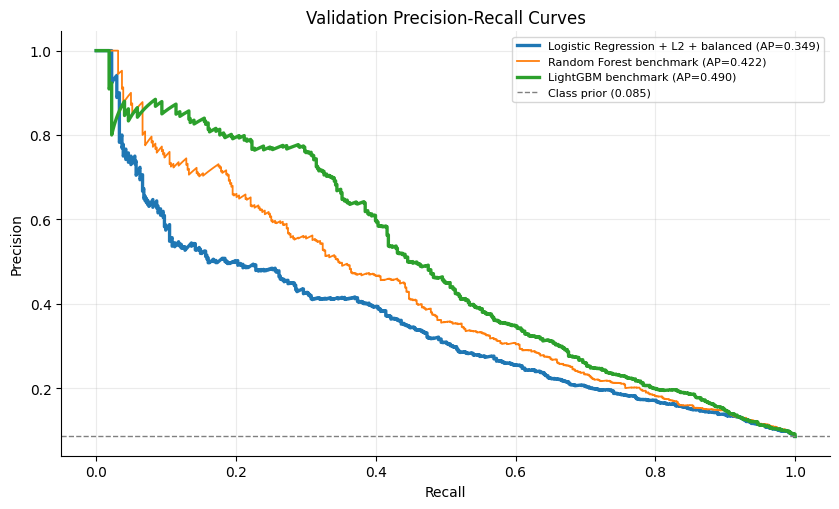

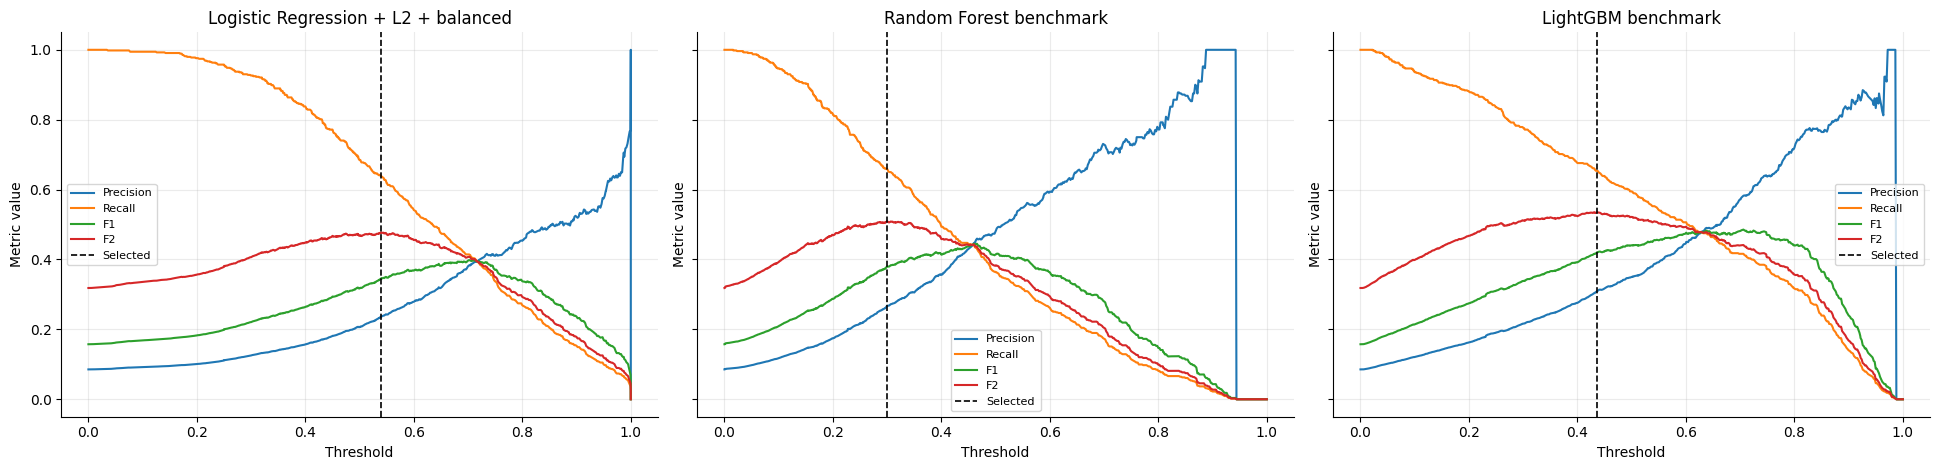

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for key, result in model_results.items():
    precision, recall, _ = precision_recall_curve(y_val, result["val_score"])
    ap = average_precision_score(y_val, result["val_score"])
    lw = 2.4 if key in [core_report_key, best_perf_key] else 1.3
    ax.plot(recall, precision, linewidth=lw, label=f"{result['display_name']} (AP={ap:.3f})")

baseline = y_val.mean()
ax.axhline(baseline, color="gray", linestyle="--", linewidth=1, label=f"Class prior ({baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Validation Precision-Recall Curves")
ax.legend(fontsize=8)
plt.tight_layout()

tradeoff_configs = [
    (key, model_results[key]["display_name"], threshold)
    for key, threshold, _ in selected_model_configs
]
fig, axes = plt.subplots(1, len(tradeoff_configs), figsize=(6.5 * len(tradeoff_configs), 4.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, (key, title, threshold) in zip(axes, tradeoff_configs):
    curve = model_results[key]["threshold_curve"].sort_values("threshold")
    ax.plot(curve["threshold"], curve["precision"], label="Precision")
    ax.plot(curve["threshold"], curve["recall"], label="Recall")
    ax.plot(curve["threshold"], curve["f1"], label="F1")
    ax.plot(curve["threshold"], curve["f2"], label="F2")
    ax.axvline(threshold, color="black", linestyle="--", linewidth=1.2, label="Selected")
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend(fontsize=8)
plt.tight_layout()


## 9. Final test evaluation

Test set chỉ được dùng sau khi đã chọn model và threshold bằng validation. Bảng dưới đây báo cáo model giải thích chính và, nếu khác, model hiệu năng tốt nhất.


In [10]:
def evaluate_result_on_test(key, threshold, label):
    result = model_results[key]
    score = result["test_score"]
    metrics = metrics_at_threshold(y_test, score, threshold)
    pred = (score >= threshold).astype(int)
    return {
        "label": label,
        "model_key": key,
        "Model": result["display_name"],
        "Group": result["group"],
        "threshold": threshold,
        "score": score,
        "pred": pred,
        "metrics": metrics,
    }

final_candidates = [
    evaluate_result_on_test(key, threshold, label)
    for key, threshold, label in selected_model_configs
]
core_final = final_candidates[0]
best_final = next((item for item in final_candidates if item["model_key"] == best_perf_key), core_final)

final_rows = []
for item in final_candidates:
    m = item["metrics"]
    final_rows.append({
        "Vai trò": item["label"],
        "Model": item["Model"],
        "Threshold": item["threshold"],
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
        "F2": m["f2"],
        "PR-AUC": m["pr_auc"],
        "ROC-AUC": m["roc_auc"],
        "TN": m["tn"],
        "FP": m["fp"],
        "FN": m["fn"],
        "TP": m["tp"],
    })

final_table = pd.DataFrame(final_rows)
display(final_table.round(4))

print("Classification report cho model hiệu năng tốt nhất:")
print(classification_report(y_test, best_final["pred"], target_names=["Normal", "Theft"], digits=4))


,Vai trò,Model,Threshold,Accuracy,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,TN,FP,FN,TP
0,Baseline tuyến tính,Logistic Regression + L2 + balanced,0.5400,0.7859,0.2162,0.5756,0.3144,0.4320,0.3117,0.7772,4683,1131,230,312
1,Bagging benchmark,Random Forest benchmark,0.3000,0.8048,0.2498,0.6439,0.3600,0.4895,0.3661,0.8092,4766,1048,193,349
2,Mô hình hiệu năng tốt nhất,LightGBM benchmark,0.4368,0.8340,0.2885,0.6458,0.3989,0.5176,0.4489,0.8387,4951,863,192,350


Classification report cho model hiệu năng tốt nhất:
              precision    recall  f1-score   support

      Normal     0.9627    0.8516    0.9037      5814
       Theft     0.2885    0.6458    0.3989       542

    accuracy                         0.8340      6356
   macro avg     0.6256    0.7487    0.6513      6356
weighted avg     0.9052    0.8340    0.8607      6356



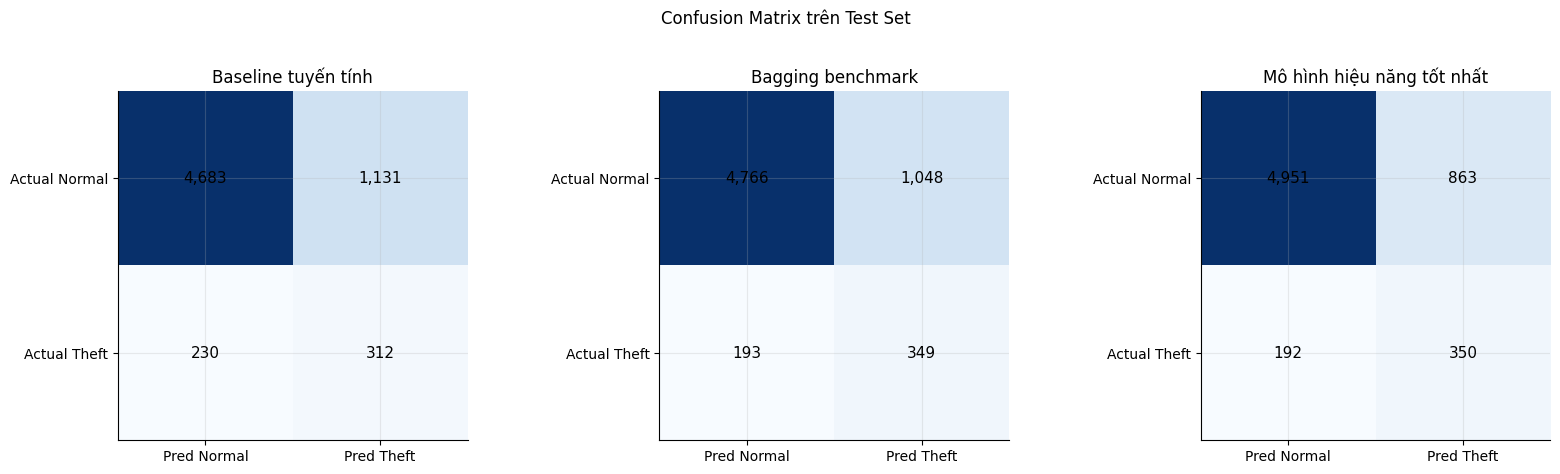

In [11]:
fig, axes = plt.subplots(1, len(final_candidates), figsize=(5.5 * len(final_candidates), 4.6))
axes = np.atleast_1d(axes)
for ax, item in zip(axes, final_candidates):
    cm = confusion_matrix(y_test, item["pred"], labels=[0, 1])
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1], labels=["Pred Normal", "Pred Theft"])
    ax.set_yticks([0, 1], labels=["Actual Normal", "Actual Theft"])
    ax.set_title(item["label"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black", fontsize=11)
fig.suptitle("Confusion Matrix trên Test Set", y=1.02)
plt.tight_layout()


## 10. Test comparison

Bảng này so sánh các model còn lại bằng threshold `best_f2` riêng của từng model, được chọn trên validation set.


In [12]:
all_test_rows = []
for key, result in model_results.items():
    threshold = float(result["threshold_choices"]["best_f2"]["threshold"])
    metrics = metrics_at_threshold(y_test, result["test_score"], threshold)
    all_test_rows.append({
        "Model": result["display_name"],
        "Group": result["group"],
        "Threshold": threshold,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "F2": metrics["f2"],
        "PR-AUC": metrics["pr_auc"],
        "ROC-AUC": metrics["roc_auc"],
        "FP": metrics["fp"],
        "FN": metrics["fn"],
        "TP": metrics["tp"],
    })

all_test_comparison = pd.DataFrame(all_test_rows).sort_values(["F2", "PR-AUC"], ascending=False)
display(all_test_comparison.round(4))


,Model,Group,Threshold,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,FP,FN,TP
2,LightGBM benchmark,Boosting,0.4368,0.2885,0.6458,0.3989,0.5176,0.4489,0.8387,863,192,350
1,Random Forest benchmark,Bagging,0.3000,0.2498,0.6439,0.3600,0.4895,0.3661,0.8092,1048,193,349
0,Logistic Regression + L2 + balanced,Linear baseline,0.5400,0.2162,0.5756,0.3144,0.4320,0.3117,0.7772,1131,230,312


## 11. Feature importance

Logistic Regression dùng hệ số chuẩn hóa để giải thích hướng tác động của feature. Tree-based models như Random Forest và LightGBM có feature importance; notebook ưu tiên hiển thị LightGBM vì đây là model hiệu năng tốt nhất trong nhóm hiện tại.


,Feature,Coefficient,Abs coefficient
86,roll30_std_avg,2.9645,2.9645
26,recent_180_mean,-2.9220,2.9220
2,std_consumption,-2.0867,2.0867
15,max_log1p_consumption,1.6092,1.6092
78,roll7_std_avg,-1.5768,1.5768
74,roll7_mean_std,-1.5206,1.5206
65,month_10_mean,-1.3392,1.3392
132,max_missing_streak_raw,1.0986,1.0986
117,weekday_std,-1.0216,1.0216
39,std_daily_change,-0.9534,0.9534


,Feature,Importance
132,max_missing_streak_raw,548
124,missing_count_raw,463
123,weekend_std_to_weekday_std_ratio,293
144,max_to_mean_ratio,242
121,weekend_weekday_log_ratio,209
91,roll90_mean_min,209
54,month_04_std,209
98,segment_1_std,207
153,missing_x_recent_drop,206
52,month_03_std,201


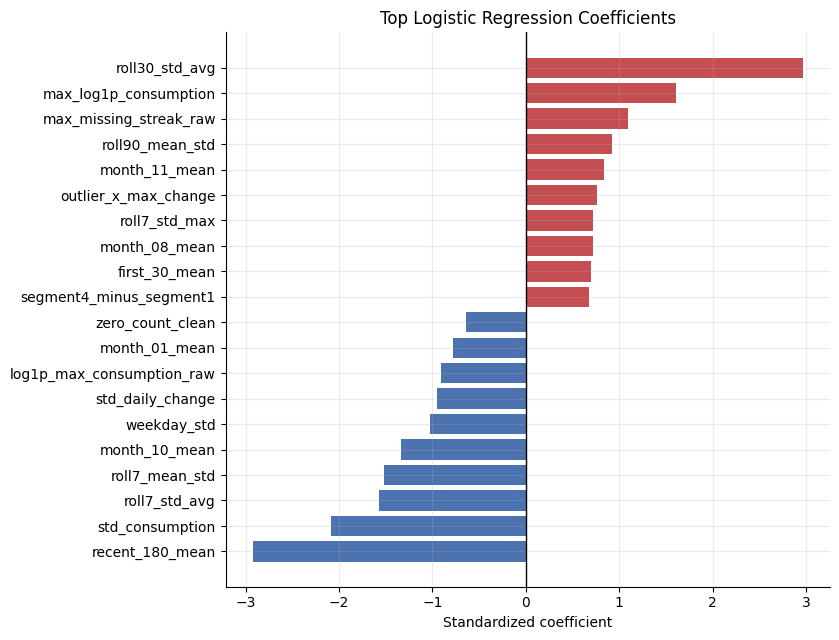

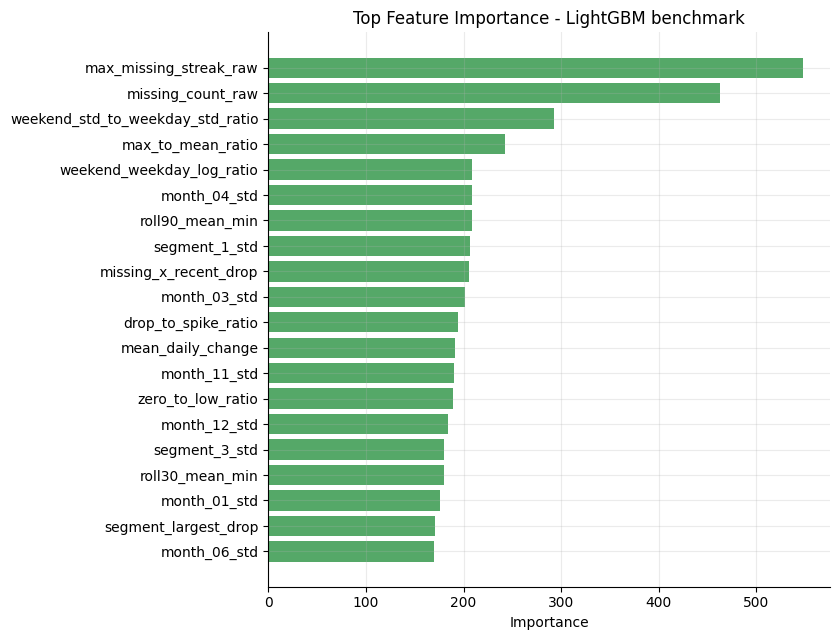

In [13]:
lr_estimator = model_results[core_report_key]["estimator"]
lr_coef = lr_estimator.named_steps["model"].coef_[0]
lr_importance = pd.DataFrame({
    "Feature": active_feature_cols,
    "Coefficient": lr_coef,
    "Abs coefficient": np.abs(lr_coef),
}).sort_values("Abs coefficient", ascending=False)

display(lr_importance.head(15).round(4))

plot_lr = pd.concat([
    lr_importance.sort_values("Coefficient").head(10),
    lr_importance.sort_values("Coefficient", ascending=False).head(10),
]).sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ["#4C72B0" if value < 0 else "#C44E52" for value in plot_lr["Coefficient"]]
ax.barh(plot_lr["Feature"], plot_lr["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Top Logistic Regression Coefficients")
ax.set_xlabel("Standardized coefficient")
plt.tight_layout()

if "lightgbm" in model_results:
    lightgbm_estimator = model_results["lightgbm"]["estimator"]
    tree_importance = pd.DataFrame({
        "Feature": active_feature_cols,
        "Importance": lightgbm_estimator.feature_importances_,
    }).sort_values("Importance", ascending=False)
    display(tree_importance.head(15))

    plot_tree = tree_importance.head(20).sort_values("Importance")
    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    ax.barh(plot_tree["Feature"], plot_tree["Importance"], color="#55A868")
    ax.set_title("Top Feature Importance - LightGBM benchmark")
    ax.set_xlabel("Importance")
    plt.tight_layout()
else:
    print("Không có LightGBM để vẽ feature importance.")


## 12. Error analysis

FN là lỗi nguy hiểm nhất: khách hàng thật sự Theft nhưng model dự đoán Normal. FP là cảnh báo nhầm: khách hàng Normal nhưng bị dự đoán Theft. Phần này phân tích lỗi của model hiệu năng tốt nhất trong các model được giữ lại.


In [14]:
analysis_item = best_final
analysis_score = analysis_item["score"]
analysis_pred = analysis_item["pred"]

error_df = pd.DataFrame({
    ID_COL: ids_test,
    "y_true": y_test,
    "score": analysis_score,
    "prediction": analysis_pred,
})
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 1) & (error_df["prediction"] == 0),
        (error_df["y_true"] == 0) & (error_df["prediction"] == 1),
        (error_df["y_true"] == 1) & (error_df["prediction"] == 1),
        (error_df["y_true"] == 0) & (error_df["prediction"] == 0),
    ],
    ["FN", "FP", "TP", "TN"],
    default="unknown",
)

display(error_df["error_type"].value_counts().reindex(["TN", "FP", "FN", "TP"]).fillna(0).astype(int).to_frame("Số lượng"))

important_cols = [
    col for col in [
        "mean_consumption",
        "std_consumption",
        "zero_ratio_clean",
        "missing_ratio_raw",
        "roll30_mean_range",
        "recent30_to_first90_ratio",
        "outlier_count_raw",
        "drop_ratio",
    ] if col in X_test.columns
]
error_view = pd.concat([error_df.reset_index(drop=True), X_test[important_cols].reset_index(drop=True)], axis=1)

print("False Negatives gần threshold nhất:")
fn_examples = error_view[error_view["error_type"] == "FN"].sort_values("score", ascending=False).head(8)
display(fn_examples.round(4))

print("False Positives score cao nhất:")
fp_examples = error_view[error_view["error_type"] == "FP"].sort_values("score", ascending=False).head(8)
display(fp_examples.round(4))

pattern_rows = []
for error_type in ["FN", "TP", "FP", "TN"]:
    subset = error_view[error_view["error_type"] == error_type]
    row = {"Nhóm": error_type, "Số lượng": len(subset), "Score trung bình": subset["score"].mean()}
    for col in important_cols:
        row[col] = subset[col].mean()
    pattern_rows.append(row)
pattern_summary = pd.DataFrame(pattern_rows)
display(pattern_summary.round(4))

print("Diễn giải ngắn: FN thường là các theft có pattern ít cực đoan hơn TP, nên score thấp hơn threshold. FP thường có tín hiệu bất thường giống theft, ví dụ dao động cao, missing/outlier hoặc thay đổi tiêu thụ mạnh.")


,Số lượng
error_type,
TN,4951
FP,863
FN,192
TP,350


False Negatives gần threshold nhất:


,CONS_NO,y_true,score,prediction,error_type,mean_consumption,std_consumption,zero_ratio_clean,missing_ratio_raw,roll30_mean_range,recent30_to_first90_ratio,outlier_count_raw,drop_ratio
904,C504734CE2C1C2D09970A8C7D49DE470,1,0.4354,0,FN,2.7695,0.9131,0.0000,0.7060,5.0830,0.3090,0,0.0000
5312,9124DDE3CEC440E94DC565CAE9CA1417,1,0.4343,0,FN,9.6674,2.1350,0.0000,0.7128,10.4093,0.7670,0,0.0029
2699,B6CF8F403CFD01A7C0B146190E74B10E,1,0.4324,0,FN,1.4668,0.4886,0.0000,0.7060,1.3853,1.1991,0,0.0010
2675,1C090A25BA5991349EB940D839A3084A,1,0.4320,0,FN,5.8578,5.8605,0.0735,0.0077,16.3560,50.0000,0,0.0058
3637,D89BE99DA4D80BF64D2BF3DABCD93312,1,0.4316,0,FN,2.1218,2.6013,0.0493,0.0135,6.1870,6.0141,0,0.0184
3690,8843BDA19C61C4479CC03970F9827C8E,1,0.4316,0,FN,1.8155,2.4186,0.3433,0.1702,7.2590,0.0088,0,0.0010
4046,2C64AF0D35DB73538B5AEC417C1826E8,1,0.4309,0,FN,7.2947,6.2307,0.0725,0.7079,37.8200,0.0000,0,0.0145
852,5A7A06B394F81AC8962C544D8F2E14E0,1,0.4294,0,FN,9.6894,9.3822,0.1992,0.0068,35.2050,0.2092,0,0.0106


False Positives score cao nhất:


,CONS_NO,y_true,score,prediction,error_type,mean_consumption,std_consumption,zero_ratio_clean,missing_ratio_raw,roll30_mean_range,recent30_to_first90_ratio,outlier_count_raw,drop_ratio
1531,0F50C6840D410322ABC114971FDEC4A2,0,0.9480,1,FP,42.0302,35.5840,0.0445,0.0010,138.7210,1.9414,0,0.0174
721,EB84A03EF05E408A5B2C236F533EF8A8,0,0.9438,1,FP,38.1053,17.1473,0.0029,0.0377,63.6197,1.4681,0,0.0058
2130,58A9AA93B0455CE70D447B13CAF9876E,0,0.9415,1,FP,407.8363,90.5230,0.0000,0.0242,276.4943,0.6645,280,0.0126
2310,EA3FA3006521F0C96DD85E0BFCB05551,0,0.9386,1,FP,4.9263,6.6229,0.0116,0.5571,28.6223,8.1142,0,0.0039
6044,32C74C931A7667CD74A47C88CEAC2920,0,0.9349,1,FP,9.1797,6.8183,0.0019,0.5019,28.6847,3.8764,0,0.0116
4852,319E672D4DD5E55F59C261EE1A41398D,0,0.9280,1,FP,26.0199,44.9872,0.2447,0.1528,111.8633,4.6676,0,0.0242
6136,2DB008896FCEEC978E2C7EF682A19FA2,0,0.9277,1,FP,12.9401,5.6398,0.0735,0.6064,27.0247,2.3114,0,0.0087
5955,E27825B7DFE82D14EB90C9F4555163A8,0,0.9237,1,FP,9.1886,8.3968,0.0039,0.0097,25.1077,3.0150,0,0.0368


,Nhóm,Số lượng,Score trung bình,mean_consumption,std_consumption,zero_ratio_clean,missing_ratio_raw,roll30_mean_range,recent30_to_first90_ratio,outlier_count_raw,drop_ratio
0,FN,192,0.2560,6.8184,3.7906,0.1360,0.2957,13.2008,3.2920,0.0104,0.0095
1,TP,350,0.7342,31.2618,16.0667,0.0860,0.3280,58.0678,4.6600,10.2371,0.0120
2,FP,863,0.6079,15.8180,8.1336,0.1165,0.3534,29.4963,5.8745,1.0023,0.0119
3,TN,4951,0.1561,6.0914,3.1413,0.2018,0.2339,10.6803,3.8378,0.0117,0.0081


Diễn giải ngắn: FN thường là các theft có pattern ít cực đoan hơn TP, nên score thấp hơn threshold. FP thường có tín hiệu bất thường giống theft, ví dụ dao động cao, missing/outlier hoặc thay đổi tiêu thụ mạnh.


## 13. Score distribution và ý nghĩa threshold

Threshold chỉ có ý nghĩa trong phân phối score của chính model đó. Vì vậy threshold của Logistic Regression + L2 + balanced, Random Forest và LightGBM không nên so trực tiếp với nhau.


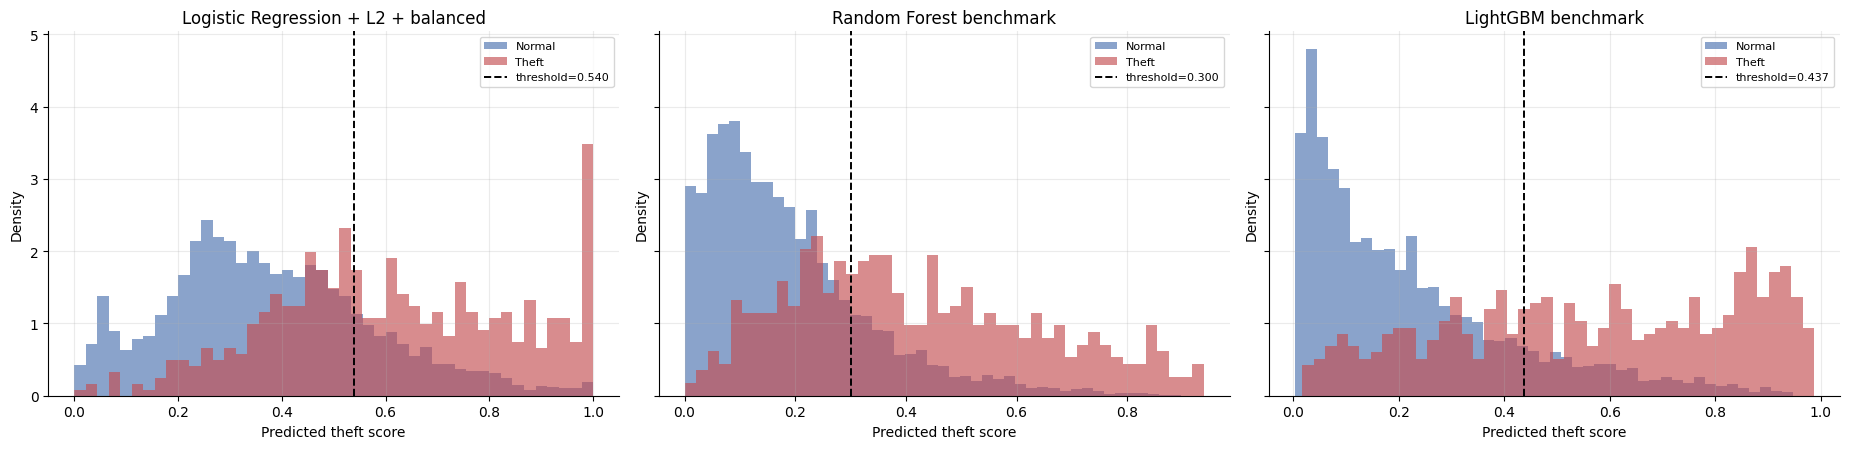

In [15]:
fig, axes = plt.subplots(1, len(final_candidates), figsize=(6.2 * len(final_candidates), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, item in zip(axes, final_candidates):
    scores = item["score"]
    ax.hist(scores[y_test == 0], bins=45, alpha=0.65, label="Normal", color="#4C72B0", density=True)
    ax.hist(scores[y_test == 1], bins=45, alpha=0.65, label="Theft", color="#C44E52", density=True)
    ax.axvline(item["threshold"], color="black", linestyle="--", linewidth=1.4, label=f"threshold={item['threshold']:.3f}")
    ax.set_title(item["Model"])
    ax.set_xlabel("Predicted theft score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
plt.tight_layout()


## 14. Gradient Descent vs Newton Method

Phần này minh họa cách Logistic Regression có thể tối ưu loss. Đây là demo phục vụ phần optimization trong báo cáo, không dùng làm model final vì scikit-learn đã có solver ổn định hơn cho training thực tế.


,Method,Iterations,Seconds,Final train loss,Val ROC-AUC,Val PR-AUC,Val F1 @0.50
0,Gradient Descent,220,0.1947,0.2756,0.7415,0.2704,0.0925
1,Newton Method,12,0.0373,0.2755,0.7434,0.2725,0.0925


Feature dùng trong optimization demo:


,Feature
0,roll30_mean_range
1,roll90_mean_range
2,roll7_mean_range
3,weekend_std
4,roll7_mean_std
5,roll30_mean_max
6,roll7_mean_max
7,roll30_mean_std
8,segment_largest_increase
9,std_consumption


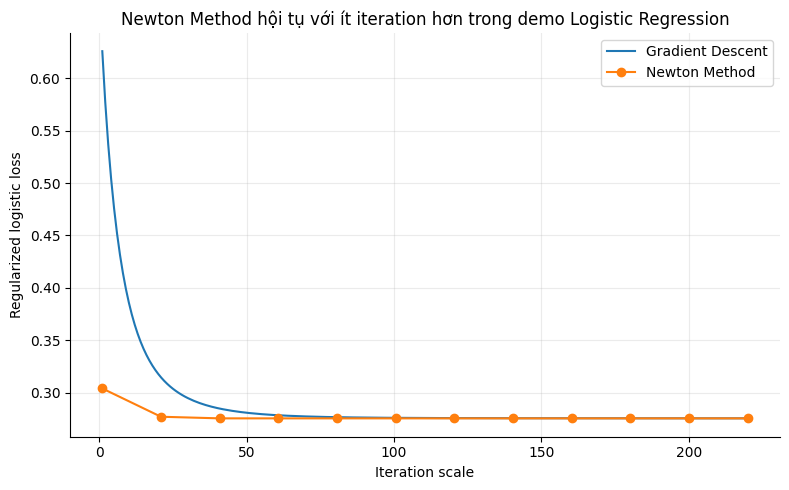

In [16]:
train_corr = X_train.apply(lambda col: np.corrcoef(col, y_train)[0, 1] if col.std() > 0 else 0).replace([np.inf, -np.inf], 0).fillna(0)
opt_features = train_corr.abs().sort_values(ascending=False).head(12).index.tolist()

scaler_opt = StandardScaler()
X_opt_train = scaler_opt.fit_transform(X_train[opt_features])
X_opt_val = scaler_opt.transform(X_val[opt_features])
y_opt_train = y_train.to_numpy(dtype=np.float64)
y_opt_val = y_val.to_numpy(dtype=np.float64)
Xb_train = np.c_[np.ones(X_opt_train.shape[0]), X_opt_train]
Xb_val = np.c_[np.ones(X_opt_val.shape[0]), X_opt_val]
reg_lambda = 1e-2


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -40, 40)))


def logistic_loss(beta, Xb, y, reg_lambda):
    p = sigmoid(Xb @ beta)
    eps = 1e-12
    loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    loss += 0.5 * reg_lambda * np.sum(beta[1:] ** 2)
    return loss


def logistic_grad(beta, Xb, y, reg_lambda):
    p = sigmoid(Xb @ beta)
    grad = Xb.T @ (p - y) / len(y)
    grad[1:] += reg_lambda * beta[1:]
    return grad


def run_gradient_descent(Xb, y, lr=0.35, n_iter=220):
    beta = np.zeros(Xb.shape[1])
    losses = []
    started = time.perf_counter()
    for _ in range(n_iter):
        beta -= lr * logistic_grad(beta, Xb, y, reg_lambda)
        losses.append(logistic_loss(beta, Xb, y, reg_lambda))
    return beta, losses, time.perf_counter() - started


def run_newton(Xb, y, n_iter=12):
    beta = np.zeros(Xb.shape[1])
    losses = []
    started = time.perf_counter()
    penalty = np.eye(Xb.shape[1]) * reg_lambda
    penalty[0, 0] = 0.0
    for _ in range(n_iter):
        p = sigmoid(Xb @ beta)
        w = p * (1 - p)
        grad = logistic_grad(beta, Xb, y, reg_lambda)
        hessian = (Xb.T * w) @ Xb / len(y) + penalty
        step = np.linalg.solve(hessian + 1e-8 * np.eye(hessian.shape[0]), grad)
        beta -= step
        losses.append(logistic_loss(beta, Xb, y, reg_lambda))
    return beta, losses, time.perf_counter() - started


beta_gd, gd_losses, gd_seconds = run_gradient_descent(Xb_train, y_opt_train)
beta_newton, newton_losses, newton_seconds = run_newton(Xb_train, y_opt_train)

opt_rows = []
for name, beta, losses, seconds in [
    ("Gradient Descent", beta_gd, gd_losses, gd_seconds),
    ("Newton Method", beta_newton, newton_losses, newton_seconds),
]:
    val_score = sigmoid(Xb_val @ beta)
    val_metrics = metrics_at_threshold(y_opt_val, val_score, 0.5)
    opt_rows.append({
        "Method": name,
        "Iterations": len(losses),
        "Seconds": seconds,
        "Final train loss": losses[-1],
        "Val ROC-AUC": val_metrics["roc_auc"],
        "Val PR-AUC": val_metrics["pr_auc"],
        "Val F1 @0.50": val_metrics["f1"],
    })

display(pd.DataFrame(opt_rows).round(4))
print("Feature dùng trong optimization demo:")
display(pd.DataFrame({"Feature": opt_features}))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(gd_losses) + 1), gd_losses, label="Gradient Descent")
ax.plot(np.linspace(1, len(gd_losses), len(newton_losses)), newton_losses, marker="o", label="Newton Method")
ax.set_xlabel("Iteration scale")
ax.set_ylabel("Regularized logistic loss")
ax.set_title("Newton Method hội tụ với ít iteration hơn trong demo Logistic Regression")
ax.legend()
plt.tight_layout()


## 15. Generalization check

So sánh train/validation/test giúp phát hiện overfitting. Với bài toán imbalanced, cần nhìn PR-AUC, Recall/F2 và số FN/FP thay vì chỉ Accuracy.


In [17]:
def score_split_for_model(key, threshold, split_name, X_part, y_part):
    result = model_results[key]
    score = safe_score(result["estimator"], X_part, result["score_kind"])
    metrics = metrics_at_threshold(y_part, score, threshold)
    return {
        "Split": split_name,
        "Model": result["display_name"],
        "Threshold": threshold,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "F2": metrics["f2"],
        "PR-AUC": metrics["pr_auc"],
        "ROC-AUC": metrics["roc_auc"],
        "FP": metrics["fp"],
        "FN": metrics["fn"],
        "TP": metrics["tp"],
    }

split_rows = []
for item in final_candidates:
    key = item["model_key"]
    threshold = item["threshold"]
    split_rows.extend([
        score_split_for_model(key, threshold, "Train", X_train, y_train),
        score_split_for_model(key, threshold, "Validation", X_val, y_val),
        score_split_for_model(key, threshold, "Test", X_test, y_test),
    ])

generalization_report = pd.DataFrame(split_rows)
display(generalization_report.round(4))


,Split,Model,Threshold,Precision,Recall,F1,F2,PR-AUC,ROC-AUC,FP,FN,TP
0,Train,Logistic Regression + L2 + balanced,0.5400,0.2343,0.6237,0.3406,0.4681,0.3263,0.7988,5158,952,1578
1,Validation,Logistic Regression + L2 + balanced,0.5400,0.2370,0.6390,0.3458,0.4772,0.3494,0.8026,1117,196,347
2,Test,Logistic Regression + L2 + balanced,0.5400,0.2162,0.5756,0.3144,0.4320,0.3117,0.7772,1131,230,312
3,Train,Random Forest benchmark,0.3000,0.4321,0.9941,0.6023,0.7888,0.8935,0.9910,3306,15,2515
4,Validation,Random Forest benchmark,0.3000,0.2668,0.6593,0.3798,0.5094,0.4219,0.8241,984,185,358
5,Test,Random Forest benchmark,0.3000,0.2498,0.6439,0.3600,0.4895,0.3661,0.8092,1048,193,349
6,Train,LightGBM benchmark,0.4368,0.4523,0.9874,0.6204,0.7984,0.8578,0.9849,3025,32,2498
7,Validation,LightGBM benchmark,0.4368,0.3103,0.6538,0.4209,0.5353,0.4902,0.8414,789,188,355
8,Test,LightGBM benchmark,0.4368,0.2885,0.6458,0.3989,0.5176,0.4489,0.8387,863,192,350


## 16. Conclusion

Notebook hiện giữ ba model để so sánh: Logistic Regression + L2 + balanced làm baseline tuyến tính, Random Forest làm bagging benchmark từ notebook first version, và LightGBM làm boosting benchmark hiệu năng chính trên feature table hiện tại.


In [18]:
core_m = core_final["metrics"]
best_m = best_final["metrics"]
rf_final = next((item for item in final_candidates if item["model_key"] == "random_forest"), None)
rf_value = "Không có Random Forest"
if rf_final is not None:
    rf_m = rf_final["metrics"]
    rf_value = f"{rf_m['recall']:.4f} / {rf_m['f1']:.4f} / {rf_m['pr_auc']:.4f}"

conclusion = pd.DataFrame({
    "Decision": [
        "Baseline tuyến tính",
        "Bagging benchmark",
        "Model hiệu năng tốt nhất",
        "Metric ưu tiên",
        "LR test Recall / F1 / PR-AUC",
        "RF test Recall / F1 / PR-AUC",
        "Best test Recall / F1 / PR-AUC",
        "Điểm đánh đổi chính",
        "Ghi chú về GD/NM",
    ],
    "Value": [
        f"{core_final['Model']} | threshold={core_final['threshold']:.4f}",
        f"{rf_final['Model']} | threshold={rf_final['threshold']:.4f}" if rf_final is not None else "Không có Random Forest",
        f"{best_final['Model']} | threshold={best_final['threshold']:.4f}",
        "Recall, F2, PR-AUC và Confusion Matrix; Accuracy chỉ dùng tham khảo",
        f"{core_m['recall']:.4f} / {core_m['f1']:.4f} / {core_m['pr_auc']:.4f}",
        rf_value,
        f"{best_m['recall']:.4f} / {best_m['f1']:.4f} / {best_m['pr_auc']:.4f}",
        "Tăng Recall thường làm tăng FP; threshold cuối nên phụ thuộc chi phí kiểm tra thực tế.",
        "GD và Newton Method được dùng để minh họa optimization, không phải model final.",
    ],
})
display(conclusion)


,Decision,Value
0,Baseline tuyến tính,Logistic Regression + L2 + balanced | threshol...
1,Bagging benchmark,Random Forest benchmark | threshold=0.3000
2,Model hiệu năng tốt nhất,LightGBM benchmark | threshold=0.4368
3,Metric ưu tiên,"Recall, F2, PR-AUC và Confusion Matrix; Accura..."
4,LR test Recall / F1 / PR-AUC,0.5756 / 0.3144 / 0.3117
5,RF test Recall / F1 / PR-AUC,0.6439 / 0.3600 / 0.3661
6,Best test Recall / F1 / PR-AUC,0.6458 / 0.3989 / 0.4489
7,Điểm đánh đổi chính,Tăng Recall thường làm tăng FP; threshold cuối...
8,Ghi chú về GD/NM,GD và Newton Method được dùng để minh họa opti...
